# Notebook 3 — Lineup Optimization under Formation Constraints

## Objective

This notebook extends the project from **matchday action allocation** to **tactical lineup construction**.

The first notebook explained the conceptual decision boundary. The second notebook showed how the current engine allocates `start`, `limit_minutes`, and `bench` decisions at squad level. This third notebook adds a missing layer required for a club-ready workflow:

> selecting a tactically feasible **starting XI** under a predefined formation while preserving the project philosophy of **risk-aware decision optimization**.

The notebook is intentionally written as a portfolio artifact for football decision intelligence. It demonstrates how a high-level policy can be reconciled with tactical feasibility through a constrained optimization model.

---

## Tactical framing

We optimize a **4-3-3** matchday plan with the following principles:

- exactly 11 starters
- role-level tactical feasibility
- risk-aware utility for each player
- controlled exposure through `limit_minutes`
- explicit comparison against the unconstrained policy baseline

This is the natural bridge from **decision engine** to **lineup design**.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc
import numpy as np
import pandas as pd
import pulp

# --- PROJECT ROOT AUTO-DETECTION ---
PROJECT_ROOT = Path().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- OPTIONAL IMPORTS FROM PROJECT ---
try:
    from src.decision import build_actions, build_thresholds, classify_decision
    PROJECT_IMPORTS_AVAILABLE = True
except Exception:
    PROJECT_IMPORTS_AVAILABLE = False

    def classify_decision(risk_score, value_score, thresholds, actions):
        is_high_risk = risk_score >= thresholds['high_risk']
        is_high_value = value_score >= thresholds['high_value']
        if is_high_risk and not is_high_value:
            return actions['high_risk_low_value'], 'High risk and low value.'
        if is_high_risk and is_high_value:
            return actions['high_risk_high_value'], 'High risk but high value.'
        return actions['low_risk'], 'Low risk.'

plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

print(f'Project root set to: {PROJECT_ROOT}')
print(f'Project imports available: {PROJECT_IMPORTS_AVAILABLE}')

Project root set to: C:\Users\manue\Projects\football-decision-engine
Project imports available: True


## 1. Construct a tactically realistic squad snapshot

The squad below is not random. It is designed to reflect a real selection problem:

- a strong first-choice spine
- several risky high-upside attackers
- multiple centre-backs competing for only two central defensive slots
- creative midfield depth with different risk profiles
- one clear low-value high-risk winger who should be deprioritized

This creates true scarcity, which the previous notebook did not fully force.


In [2]:
squad = pd.DataFrame([
    ['P01', 'GK1', 'GK', 'Goalkeeper', 0.08, 0.64, 'Starting goalkeeper', ['GK']],
    ['P02', 'GK2', 'GK', 'Goalkeeper', 0.12, 0.34, 'Backup goalkeeper', ['GK']],
    ['P03', 'RB1', 'RB', 'Defence', 0.24, 0.71, 'Reliable full-back', ['RB']],
    ['P04', 'CB1', 'CB', 'Defence', 0.21, 0.84, 'Core centre-back', ['RCB', 'LCB']],
    ['P05', 'CB2', 'CB', 'Defence', 0.33, 0.76, 'Complementary centre-back', ['RCB', 'LCB']],
    ['P06', 'LB1', 'LB', 'Defence', 0.28, 0.72, 'Two-way full-back', ['LB']],
    ['P07', 'DM1', 'DM', 'Midfield', 0.29, 0.81, 'Ball-winning anchor', ['DM', 'RCM', 'LCM']],
    ['P08', 'CM1', 'CM', 'Midfield', 0.38, 0.74, 'Progressor', ['RCM', 'LCM']],
    ['P09', 'AM1', 'AM', 'Midfield', 0.42, 0.86, 'Primary creator', ['RCM', 'LCM']],
    ['P10', 'RW1', 'RW', 'Attack', 0.74, 0.93, 'Explosive winger, monitored load', ['RW']],
    ['P11', 'LW1', 'LW', 'Attack', 0.69, 0.82, 'High-upside wide threat', ['LW']],
    ['P12', 'ST1', 'ST', 'Attack', 0.58, 0.89, 'First-choice striker', ['ST']],
    ['P13', 'FB2', 'FB', 'Defence', 0.54, 0.55, 'Rotation full-back', ['RB', 'LB']],
    ['P14', 'CB3', 'CB', 'Defence', 0.63, 0.60, 'Risky depth centre-back', ['RCB', 'LCB']],
    ['P15', 'CM2', 'CM', 'Midfield', 0.65, 0.77, 'High-value midfielder with elevated risk', ['RCM', 'LCM']],
    ['P16', 'W2', 'W', 'Attack', 0.81, 0.68, 'Direct winger with high exposure', ['RW', 'LW']],
    ['P17', 'ST2', 'ST', 'Attack', 0.31, 0.57, 'Bench striker', ['ST']],
    ['P18', 'AM2', 'AM', 'Midfield', 0.72, 0.79, 'Creative option with risk flag', ['RCM', 'LCM']],
    ['P19', 'DM2', 'DM', 'Midfield', 0.61, 0.52, 'Protective midfielder, low upside', ['DM', 'RCM', 'LCM']],
    ['P20', 'CB4', 'CB', 'Defence', 0.46, 0.49, 'Depth centre-back', ['RCB', 'LCB']],
    ['P21', 'W3', 'W', 'Attack', 0.77, 0.44, 'Low-value high-risk winger', ['RW', 'LW']],
])

squad.columns = [
    'player_id', 'player_name', 'position', 'unit', 'risk_score', 'value_score', 'context_note', 'eligible_slots'
]

squad

,player_id,player_name,position,unit,risk_score,value_score,context_note,eligible_slots
0,P01,GK1,GK,Goalkeeper,0.08,0.64,Starting goalkeeper,[GK]
1,P02,GK2,GK,Goalkeeper,0.12,0.34,Backup goalkeeper,[GK]
2,P03,RB1,RB,Defence,0.24,0.71,Reliable full-back,[RB]
3,P04,CB1,CB,Defence,0.21,0.84,Core centre-back,"[RCB, LCB]"
4,P05,CB2,CB,Defence,0.33,0.76,Complementary centre-back,"[RCB, LCB]"
5,P06,LB1,LB,Defence,0.28,0.72,Two-way full-back,[LB]
6,P07,DM1,DM,Midfield,0.29,0.81,Ball-winning anchor,"[DM, RCM, LCM]"
7,P08,CM1,CM,Midfield,0.38,0.74,Progressor,"[RCM, LCM]"
8,P09,AM1,AM,Midfield,0.42,0.86,Primary creator,"[RCM, LCM]"
9,P10,RW1,RW,Attack,0.74,0.93,"Explosive winger, monitored load",[RW]


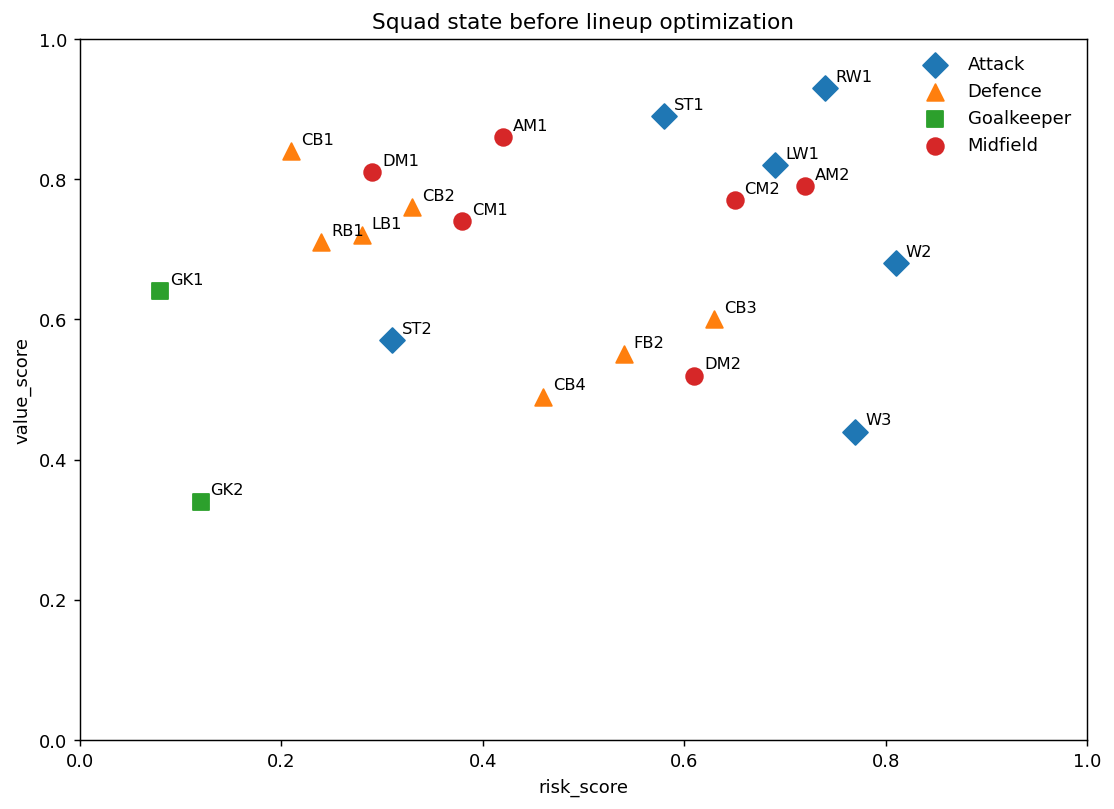

In [3]:
unit_style = {
    'Attack': ('D', 95),
    'Defence': ('^', 85),
    'Goalkeeper': ('s', 85),
    'Midfield': ('o', 85),
}

fig, ax = plt.subplots(figsize=(10, 7))
for unit, frame in squad.groupby('unit'):
    marker, size = unit_style[unit]
    ax.scatter(frame['risk_score'], frame['value_score'], label=unit, marker=marker, s=size)
    for _, row in frame.iterrows():
        ax.annotate(row['player_name'], (row['risk_score'] + 0.01, row['value_score'] + 0.01), fontsize=9)

ax.set_title('Squad state before lineup optimization')
ax.set_xlabel('risk_score')
ax.set_ylabel('value_score')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False)
plt.show()

## 2. Reconstruct the current project policy

To stay aligned with the project, we use the same policy logic already established in the codebase and documentation:

- `high_risk_threshold = 0.70`
- `high_value_threshold = 0.60`
- `risk_penalty = 0.50`
- `high_risk + high_value -> limit_minutes`
- `high_risk + low_value -> bench`
- otherwise -> `start`

This gives us a transparent baseline before tactical constraints are introduced.


In [4]:
policy = {
    'policy_name': 'default_milp_policy',
    'thresholds': {'high_risk': 0.70, 'high_value': 0.60},
    'actions': {
        'high_risk_low_value': 'bench',
        'high_risk_high_value': 'limit_minutes',
        'low_risk': 'start',
    },
    'optimization': {'risk_penalty': 0.50},
    'tactical_constraints': {
        'formation': '4-3-3',
        'n_starters': 11,
        'max_limit_minutes': 3,
    },
}

if PROJECT_IMPORTS_AVAILABLE:
    thresholds = build_thresholds(policy)
    actions = build_actions(policy)
else:
    thresholds = policy['thresholds']
    actions = policy['actions']

pd.DataFrame([
    {
        'policy_name': policy['policy_name'],
        'high_risk_threshold': policy['thresholds']['high_risk'],
        'high_value_threshold': policy['thresholds']['high_value'],
        'risk_penalty': policy['optimization']['risk_penalty'],
        'formation': policy['tactical_constraints']['formation'],
        'n_starters': policy['tactical_constraints']['n_starters'],
        'max_limit_minutes': policy['tactical_constraints']['max_limit_minutes'],
    }
])

,policy_name,high_risk_threshold,high_value_threshold,risk_penalty,formation,n_starters,max_limit_minutes
0,default_milp_policy,0.7,0.6,0.5,4-3-3,11,3


## 3. Compute the unconstrained policy baseline

This baseline mirrors the current decision logic but does **not** enforce lineup realism.

It answers the question:

> what would the project recommend **before** we force a valid starting XI?


In [5]:
policy_results = squad.apply(
    lambda row: classify_decision(
        risk_score=float(row['risk_score']),
        value_score=float(row['value_score']),
        thresholds=thresholds,
        actions=actions,
    ),
    axis=1,
    result_type='expand'
)

policy_results.columns = ['policy_decision', 'policy_reason']
lineup = pd.concat([squad.copy(), policy_results], axis=1)
lineup['base_score'] = lineup['value_score'] - policy['optimization']['risk_penalty'] * lineup['risk_score']
lineup['priority_score'] = lineup['base_score']

lineup[['player_name', 'position', 'risk_score', 'value_score', 'policy_decision', 'base_score']].sort_values(
    ['policy_decision', 'base_score'], ascending=[True, False]
)

,player_name,position,risk_score,value_score,policy_decision,base_score
20,W3,W,0.77,0.44,bench,0.055
9,RW1,RW,0.74,0.93,limit_minutes,0.560
17,AM2,AM,0.72,0.79,limit_minutes,0.430
15,W2,W,0.81,0.68,limit_minutes,0.275
3,CB1,CB,0.21,0.84,start,0.735
6,DM1,DM,0.29,0.81,start,0.665
8,AM1,AM,0.42,0.86,start,0.650
11,ST1,ST,0.58,0.89,start,0.600
0,GK1,GK,0.08,0.64,start,0.600
4,CB2,CB,0.33,0.76,start,0.595


In [6]:
policy_mix = (
    lineup['policy_decision']
    .value_counts()
    .rename_axis('policy_decision')
    .reset_index(name='n_players')
)

policy_mix

,policy_decision,n_players
0,start,17
1,limit_minutes,3
2,bench,1


## 4. Why the baseline is not enough

The unconstrained baseline is still useful, but it does not answer the staff's real question.

A coaching staff does not need 17 or 18 generic `start` labels. It needs:

- one goalkeeper
- a valid back four
- a valid midfield three
- a valid front three
- a defensible explanation for which players are protected or left out

That is why we now formulate a formation-aware MILP.


## 5. Tactical optimization model

### Formation
We solve a **4-3-3** with the following starting slots:

- `GK`
- `RB`, `RCB`, `LCB`, `LB`
- `DM`, `RCM`, `LCM`
- `RW`, `ST`, `LW`

### Decision variables
For each player, we still preserve the three matchday actions used by the project:

- `start`
- `limit_minutes`
- `bench`

For starters, we also assign a specific tactical slot.

### Objective intuition
We maximize total squad utility with the following behavior:

- starters receive the highest upside, but risky starters are penalized
- `limit_minutes` protects valuable risky players
- `bench` becomes the low-contribution fallback

This creates a realistic trade-off between **selection quality**, **risk exposure**, and **tactical feasibility**.


In [7]:
formation_slots = ['GK', 'RB', 'RCB', 'LCB', 'LB', 'DM', 'RCM', 'LCM', 'RW', 'ST', 'LW']
player_ids = lineup['player_id'].tolist()
player_name_map = dict(zip(lineup['player_id'], lineup['player_name']))
row_index = dict(zip(lineup['player_id'], lineup.index))

risk_penalty = policy['optimization']['risk_penalty']
max_limit_minutes = policy['tactical_constraints']['max_limit_minutes']

# Utility construction aligned with the project philosophy.
lineup['u_start'] = lineup['base_score'] - 0.20 * lineup['risk_score']
lineup['u_limit'] = lineup['base_score']
lineup['u_bench'] = 0.20 * lineup['base_score']

# Optional slot bonus: small reward for players with strong value and natural fit in scarce roles.
slot_bonus = {
    'GK': 0.03, 'RB': 0.02, 'RCB': 0.02, 'LCB': 0.02, 'LB': 0.02,
    'DM': 0.03, 'RCM': 0.02, 'LCM': 0.02,
    'RW': 0.03, 'ST': 0.04, 'LW': 0.03,
}

model = pulp.LpProblem('formation_constrained_lineup', pulp.LpMaximize)

x_limit = pulp.LpVariable.dicts('limit_minutes', player_ids, cat='Binary')
x_bench = pulp.LpVariable.dicts('bench', player_ids, cat='Binary')
x_slot = {
    (pid, slot): pulp.LpVariable(f'start_{pid}_{slot}', cat='Binary')
    for pid in player_ids
    for slot in formation_slots
}

# Objective
model += pulp.lpSum(
    (float(lineup.loc[row_index[pid], 'u_limit'])) * x_limit[pid]
    + (float(lineup.loc[row_index[pid], 'u_bench'])) * x_bench[pid]
    + pulp.lpSum(
        (float(lineup.loc[row_index[pid], 'u_start']) + slot_bonus[slot]) * x_slot[(pid, slot)]
        for slot in formation_slots
    )
    for pid in player_ids
)

# Each player receives exactly one action: one starting slot OR limit OR bench.
for pid in player_ids:
    model += (
        pulp.lpSum(x_slot[(pid, slot)] for slot in formation_slots) + x_limit[pid] + x_bench[pid] == 1,
        f'one_action_{pid}'
    )

# Each tactical slot must be filled exactly once.
for slot in formation_slots:
    model += (
        pulp.lpSum(x_slot[(pid, slot)] for pid in player_ids) == 1,
        f'fill_slot_{slot}'
    )

# Enforce slot eligibility.
for _, row in lineup.iterrows():
    pid = row['player_id']
    eligible = set(row['eligible_slots'])
    for slot in formation_slots:
        if slot not in eligible:
            model += x_slot[(pid, slot)] == 0, f'eligibility_{pid}_{slot}'

# Exposure management.
model += pulp.lpSum(x_limit[pid] for pid in player_ids) <= max_limit_minutes, 'max_limit_minutes'

solver = pulp.PULP_CBC_CMD(msg=False)
model.solve(solver)
status = pulp.LpStatus[model.status]
print('Solver status:', status)

Solver status: Optimal


In [8]:
if status != 'Optimal':
    raise RuntimeError(f'Lineup optimization failed. Solver status: {status}')

final_decision = []
assigned_slot = []
final_utility = []

for pid in player_ids:
    player_row = lineup.loc[row_index[pid]]
    slot_assignment = None
    for slot in formation_slots:
        if pulp.value(x_slot[(pid, slot)]) == 1:
            slot_assignment = slot
            break

    if slot_assignment is not None:
        decision = 'start'
        utility = float(player_row['u_start']) + slot_bonus[slot_assignment]
    elif pulp.value(x_limit[pid]) == 1:
        decision = 'limit_minutes'
        utility = float(player_row['u_limit'])
    else:
        decision = 'bench'
        utility = float(player_row['u_bench'])

    final_decision.append(decision)
    assigned_slot.append(slot_assignment)
    final_utility.append(utility)

lineup['final_decision'] = final_decision
lineup['assigned_slot'] = assigned_slot
lineup['final_utility'] = final_utility
lineup['changed_by_optimization'] = lineup['policy_decision'] != lineup['final_decision']

lineup[['player_name', 'position', 'risk_score', 'value_score', 'policy_decision', 'final_decision', 'assigned_slot', 'priority_score', 'final_utility', 'changed_by_optimization']].sort_values(
    ['final_decision', 'assigned_slot', 'priority_score'], ascending=[True, True, False]
)

,player_name,position,risk_score,value_score,policy_decision,final_decision,assigned_slot,priority_score,final_utility,changed_by_optimization
13,CB3,CB,0.63,0.60,start,bench,NaN,0.285,0.057,True
1,GK2,GK,0.12,0.34,start,bench,NaN,0.280,0.056,True
12,FB2,FB,0.54,0.55,start,bench,NaN,0.280,0.056,True
15,W2,W,0.81,0.68,limit_minutes,bench,NaN,0.275,0.055,True
19,CB4,CB,0.46,0.49,start,bench,NaN,0.260,0.052,True
18,DM2,DM,0.61,0.52,start,bench,NaN,0.215,0.043,True
20,W3,W,0.77,0.44,bench,bench,NaN,0.055,0.011,False
11,ST1,ST,0.58,0.89,start,limit_minutes,NaN,0.600,0.600,True
14,CM2,CM,0.65,0.77,start,limit_minutes,NaN,0.445,0.445,True
17,AM2,AM,0.72,0.79,limit_minutes,limit_minutes,NaN,0.430,0.430,False


## 6. Final starting XI by tactical slot

This is the core output that a staff would actually consume: a valid lineup, not just a list of high-priority players.


In [9]:
starting_xi = lineup.loc[lineup['final_decision'] == 'start', [
    'assigned_slot', 'player_name', 'position', 'unit', 'risk_score', 'value_score', 'priority_score', 'context_note'
]].sort_values('assigned_slot')

starting_xi

,assigned_slot,player_name,position,unit,risk_score,value_score,priority_score,context_note
6,DM,DM1,DM,Midfield,0.29,0.81,0.665,Ball-winning anchor
0,GK,GK1,GK,Goalkeeper,0.08,0.64,0.600,Starting goalkeeper
5,LB,LB1,LB,Defence,0.28,0.72,0.580,Two-way full-back
3,LCB,CB1,CB,Defence,0.21,0.84,0.735,Core centre-back
7,LCM,CM1,CM,Midfield,0.38,0.74,0.550,Progressor
10,LW,LW1,LW,Attack,0.69,0.82,0.475,High-upside wide threat
2,RB,RB1,RB,Defence,0.24,0.71,0.590,Reliable full-back
4,RCB,CB2,CB,Defence,0.33,0.76,0.595,Complementary centre-back
8,RCM,AM1,AM,Midfield,0.42,0.86,0.650,Primary creator
9,RW,RW1,RW,Attack,0.74,0.93,0.560,"Explosive winger, monitored load"


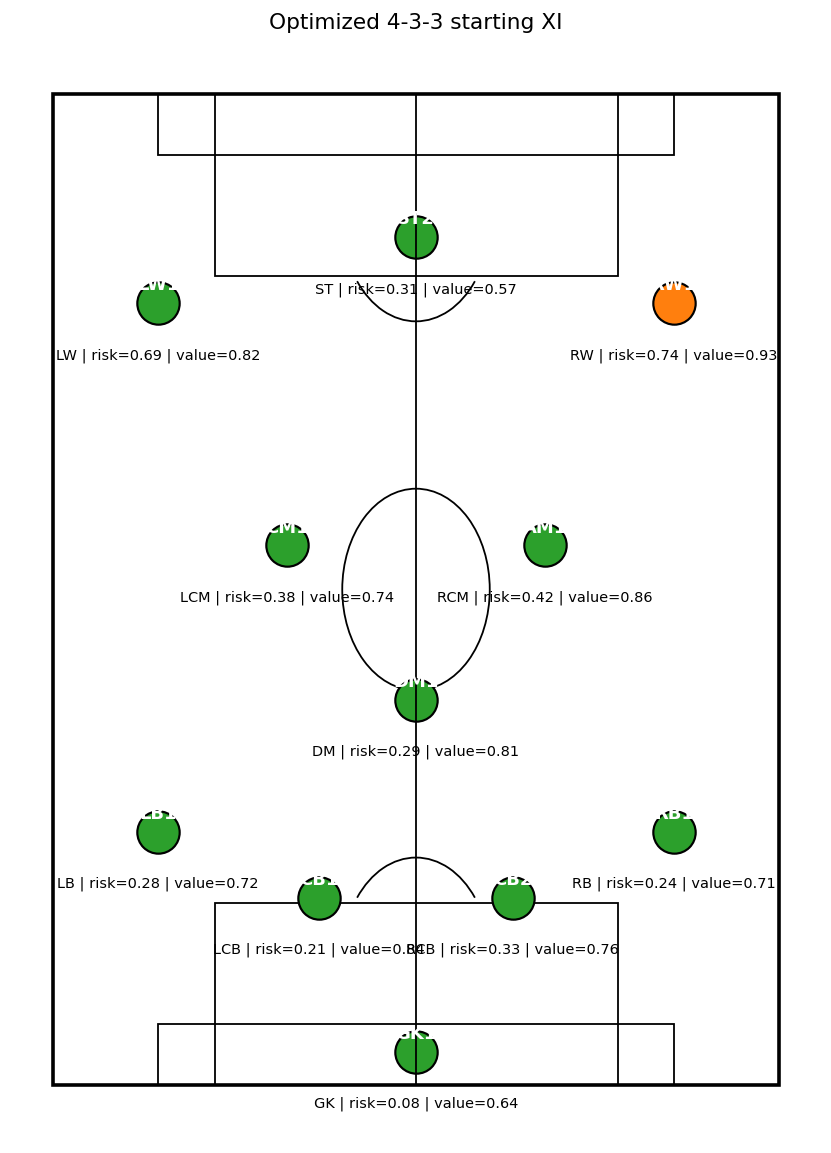

In [10]:
slot_order = ['GK', 'RB', 'RCB', 'LCB', 'LB', 'DM', 'RCM', 'LCM', 'RW', 'ST', 'LW']
slot_positions = {
    'GK': (50, 8),
    'RB': (82, 28), 'RCB': (62, 22), 'LCB': (38, 22), 'LB': (18, 28),
    'DM': (50, 40), 'RCM': (66, 54), 'LCM': (34, 54),
    'RW': (82, 76), 'ST': (50, 82), 'LW': (18, 76),
}

fig, ax = plt.subplots(figsize=(8, 11))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.add_patch(Rectangle((5, 5), 90, 90, fill=False, linewidth=2))
ax.plot([50, 50], [5, 95], color='black', linewidth=1)
ax.add_patch(plt.Circle((50, 50), 9.15, fill=False, color='black', linewidth=1))
ax.add_patch(Rectangle((25, 5), 50, 16.5, fill=False, linewidth=1))
ax.add_patch(Rectangle((18, 5), 64, 5.5, fill=False, linewidth=1))
ax.add_patch(Rectangle((25, 78.5), 50, 16.5, fill=False, linewidth=1))
ax.add_patch(Rectangle((18, 89.5), 64, 5.5, fill=False, linewidth=1))
ax.add_patch(Arc((50, 16.5), 18.3, 18.3, angle=0, theta1=37, theta2=143, linewidth=1))
ax.add_patch(Arc((50, 83.5), 18.3, 18.3, angle=0, theta1=217, theta2=323, linewidth=1))

for slot in slot_order:
    player = starting_xi.loc[starting_xi['assigned_slot'] == slot].iloc[0]
    x, y = slot_positions[slot]
    color = 'tab:green' if player['risk_score'] < 0.70 else 'tab:orange'
    ax.scatter(x, y, s=550, color=color, edgecolor='black', linewidth=1.2)
    ax.text(x, y + 1.7, player['player_name'], ha='center', va='center', fontsize=10, color='white', weight='bold')
    ax.text(x, y - 5.0, f"{slot} | risk={player['risk_score']:.2f} | value={player['value_score']:.2f}", ha='center', fontsize=8)

ax.set_title('Optimized 4-3-3 starting XI')
ax.axis('off')
plt.show()

## 7. Controlled exposure and deprioritized players

A lineup problem is not only about starters. It is also about who is protected and who is deprioritized.


In [11]:
limit_group = lineup.loc[lineup['final_decision'] == 'limit_minutes', [
    'player_name', 'position', 'risk_score', 'value_score', 'priority_score', 'context_note'
]].sort_values('priority_score', ascending=False)

bench_group = lineup.loc[lineup['final_decision'] == 'bench', [
    'player_name', 'position', 'risk_score', 'value_score', 'priority_score', 'context_note'
]].sort_values('priority_score', ascending=False)

print('Players assigned to limit_minutes')
display(limit_group)
print('')
print('Players assigned to bench')
display(bench_group)

Players assigned to limit_minutes


,player_name,position,risk_score,value_score,priority_score,context_note
11,ST1,ST,0.58,0.89,0.600,First-choice striker
14,CM2,CM,0.65,0.77,0.445,High-value midfielder with elevated risk
17,AM2,AM,0.72,0.79,0.430,Creative option with risk flag



Players assigned to bench


,player_name,position,risk_score,value_score,priority_score,context_note
13,CB3,CB,0.63,0.60,0.285,Risky depth centre-back
1,GK2,GK,0.12,0.34,0.280,Backup goalkeeper
12,FB2,FB,0.54,0.55,0.280,Rotation full-back
15,W2,W,0.81,0.68,0.275,Direct winger with high exposure
19,CB4,CB,0.46,0.49,0.260,Depth centre-back
18,DM2,DM,0.61,0.52,0.215,"Protective midfielder, low upside"
20,W3,W,0.77,0.44,0.055,Low-value high-risk winger


## 8. Policy baseline vs formation-constrained optimization

This is the most important analytical comparison in the notebook.

The baseline policy says who is generally safe or valuable enough to start. The tactical MILP decides **who can actually start together** in a valid formation.


In [12]:
summary_metrics = pd.DataFrame([
    ['Squad size', len(lineup)],
    ['Policy starts', int((lineup['policy_decision'] == 'start').sum())],
    ['Policy limit_minutes', int((lineup['policy_decision'] == 'limit_minutes').sum())],
    ['Policy bench', int((lineup['policy_decision'] == 'bench').sum())],
    ['Final starts', int((lineup['final_decision'] == 'start').sum())],
    ['Final limit_minutes', int((lineup['final_decision'] == 'limit_minutes').sum())],
    ['Final bench', int((lineup['final_decision'] == 'bench').sum())],
    ['Players changed by optimization', int(lineup['changed_by_optimization'].sum())],
])
summary_metrics.columns = ['metric', 'value']
summary_metrics

,metric,value
0,Squad size,21
1,Policy starts,17
2,Policy limit_minutes,3
3,Policy bench,1
4,Final starts,11
5,Final limit_minutes,3
6,Final bench,7
7,Players changed by optimization,9


In [13]:
transition_summary = (
    lineup.groupby(['policy_decision', 'final_decision'])
    .size()
    .reset_index(name='n_players')
    .sort_values('n_players', ascending=False)
)

transition_summary

,policy_decision,final_decision,n_players
6,start,start,10
4,start,bench,5
5,start,limit_minutes,2
2,limit_minutes,limit_minutes,1
1,limit_minutes,bench,1
0,bench,bench,1
3,limit_minutes,start,1


In [14]:
changed_players = lineup.loc[lineup['changed_by_optimization'], [
    'player_name', 'position', 'risk_score', 'value_score', 'policy_decision', 'final_decision', 'assigned_slot', 'priority_score', 'context_note'
]].sort_values(['final_decision', 'priority_score'], ascending=[True, False])

changed_players

,player_name,position,risk_score,value_score,policy_decision,final_decision,assigned_slot,priority_score,context_note
13,CB3,CB,0.63,0.60,start,bench,NaN,0.285,Risky depth centre-back
1,GK2,GK,0.12,0.34,start,bench,NaN,0.280,Backup goalkeeper
12,FB2,FB,0.54,0.55,start,bench,NaN,0.280,Rotation full-back
15,W2,W,0.81,0.68,limit_minutes,bench,NaN,0.275,Direct winger with high exposure
19,CB4,CB,0.46,0.49,start,bench,NaN,0.260,Depth centre-back
18,DM2,DM,0.61,0.52,start,bench,NaN,0.215,"Protective midfielder, low upside"
11,ST1,ST,0.58,0.89,start,limit_minutes,NaN,0.600,First-choice striker
14,CM2,CM,0.65,0.77,start,limit_minutes,NaN,0.445,High-value midfielder with elevated risk
9,RW1,RW,0.74,0.93,limit_minutes,start,RW,0.560,"Explosive winger, monitored load"


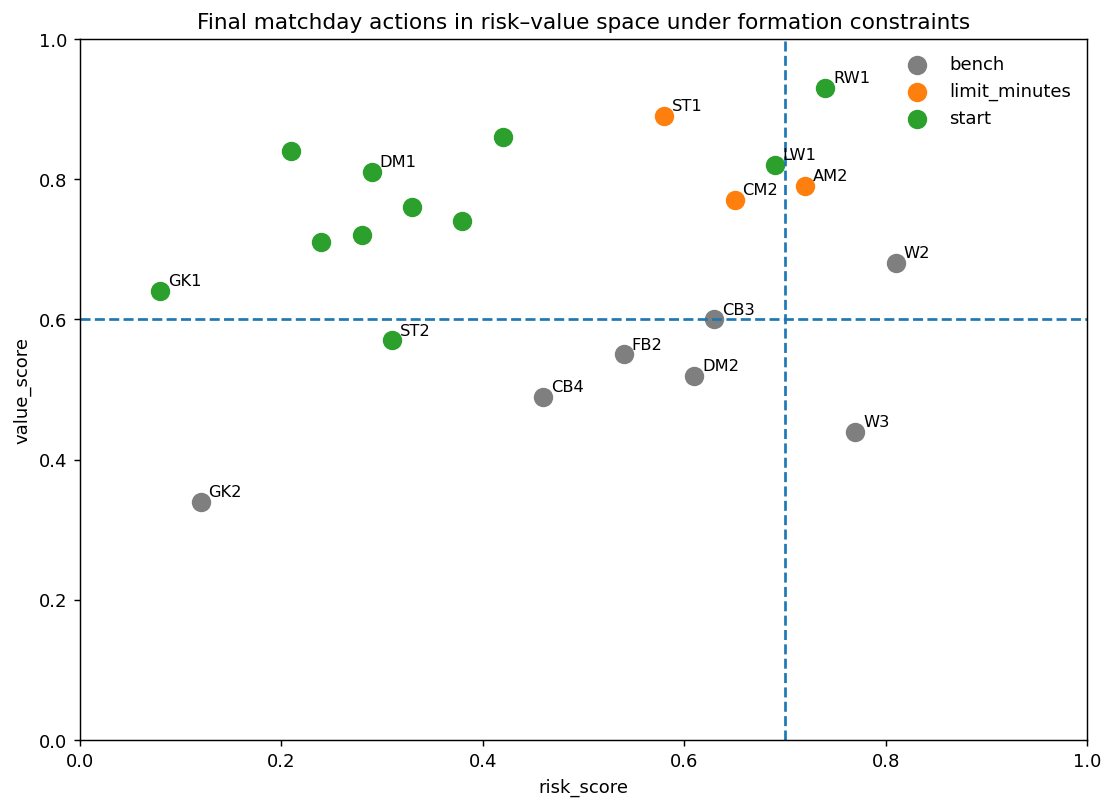

In [15]:
decision_code = {'bench': 0, 'limit_minutes': 1, 'start': 2}
fig, ax = plt.subplots(figsize=(10, 7))
colors = {'start': 'tab:green', 'limit_minutes': 'tab:orange', 'bench': 'tab:gray'}

for decision, frame in lineup.groupby('final_decision'):
    ax.scatter(frame['risk_score'], frame['value_score'], s=95, color=colors[decision], label=decision)
    for _, row in frame.iterrows():
        label = row['player_name'] if row['final_decision'] != 'start' or row['assigned_slot'] in ['GK', 'DM', 'ST', 'RW', 'LW'] else ''
        if label:
            ax.annotate(label, (row['risk_score'] + 0.008, row['value_score'] + 0.008), fontsize=9)

ax.axvline(policy['thresholds']['high_risk'], linestyle='--')
ax.axhline(policy['thresholds']['high_value'], linestyle='--')
ax.set_title('Final matchday actions in risk–value space under formation constraints')
ax.set_xlabel('risk_score')
ax.set_ylabel('value_score')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False)
plt.show()

## 9. Position-level selection pressure

This table makes the tactical scarcity explicit.

Some players are downgraded not because they are poor players, but because the formation only opens a limited number of structurally valid slots.


In [16]:
position_pressure = (
    lineup.groupby(['position', 'final_decision'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

position_pressure

final_decision,position,bench,limit_minutes,start
0,AM,0,1,1
1,CB,2,0,2
2,CM,0,1,1
3,DM,1,0,1
4,FB,1,0,0
5,GK,1,0,1
6,LB,0,0,1
7,LW,0,0,1
8,RB,0,0,1
9,RW,0,0,1


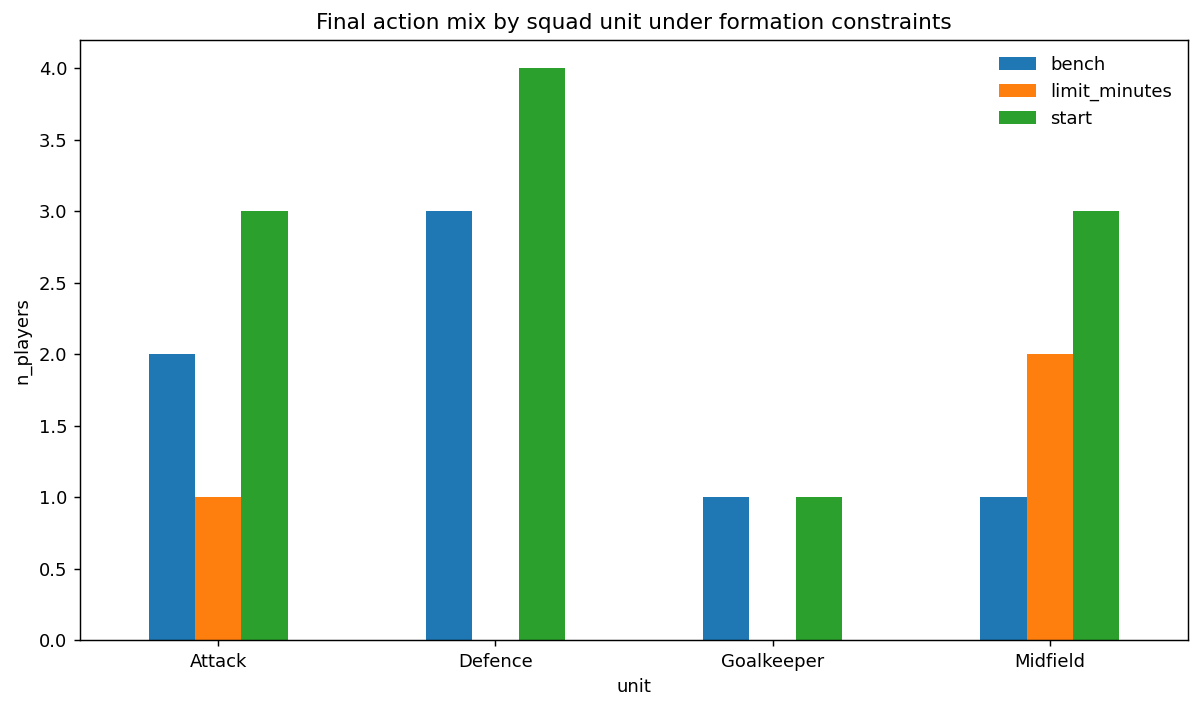

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = lineup.groupby(['unit', 'final_decision']).size().unstack(fill_value=0)
plot_df[['bench', 'limit_minutes', 'start']].plot(kind='bar', ax=ax)
ax.set_title('Final action mix by squad unit under formation constraints')
ax.set_xlabel('unit')
ax.set_ylabel('n_players')
ax.legend(frameon=False)
plt.xticks(rotation=0)
plt.show()

## 10. Executive conclusions

This notebook completes the transition from isolated decision rules to a fully constrained matchday decision system.

### From policy to reality

The policy layer initially classifies a large portion of the squad as `start` (17 players), reflecting value-driven prioritization without structural constraints.

However, the optimization layer enforces real-world limitations:

* only 11 players can start
* formation constraints must be respected (4-3-3)
* risk exposure must be managed globally

As a result:

* several `start` decisions are overridden to `bench`
* high-risk players are selectively reassigned to `limit_minutes`
* the final lineup reflects both value maximization and feasibility

### Risk-aware optimization

The optimizer does not simply select the highest-value players.

Instead, it balances:

* individual player value
* injury/exposure risk
* positional requirements

Key examples:

* **ST1 (high value)** is moved to `limit_minutes` due to elevated risk
* **ST2 (lower value, lower risk)** is selected as starting striker
* **RW1 (high value, high risk)** is still started, indicating that extreme value can justify risk

This demonstrates a non-trivial trade-off:

> maximizing expected contribution while controlling aggregate risk

### Policy vs optimization divergence

A total of **9 players change their decision** after optimization.

This highlights:

* policy rules are necessary but insufficient
* global constraints fundamentally reshape decisions
* optimal solutions emerge only when considering the squad jointly

### Structural realism

The final lineup:

* satisfies all positional constraints
* respects the 4-3-3 formation
* distributes roles coherently across units (defence, midfield, attack)

Additionally:

* bench composition removes low-value or redundant profiles
* `limit_minutes` is used strategically for high-impact but risky players

### System-level insight

This notebook demonstrates that:

> Optimal football decisions are not player-level decisions, but system-level allocations under constraints.

The model successfully integrates:

* evaluation (risk/value scoring)
* decision policy (rule-based layer)
* optimization (MILP under constraints)

### Key takeaway

The transition is complete:

**Prediction → Policy → Optimization → Decision System**

This provides a foundation for:

* multi-match planning
* load management across fixtures
* dynamic policy tuning under different contexts

### Why this matters for the project

This notebook upgrades the project from:

> player-level recommendation → squad-level matchday planning → **tactical lineup optimization**

That is the key step that makes the portfolio more credible for clubs, football consultancies, and sports decision-support roles.


## 11. High-value next steps

The next natural extensions are:

- opponent-adjusted formation choice
- positional redundancy constraints for the bench
- tactical chemistry or pairing bonuses
- fatigue carry-over across match congestion
- scenario simulation across multiple match plans

At that point, the system becomes a true **football decision engine for lineup design under uncertainty**.
